# Time Series Analysis: Clustering

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import meteostat as ms
from datetime import datetime

In [5]:
bolzano = ms.Point(46.5, 11.35, 262)  

# Get nearby weather stations
stations = ms.stations.nearby(bolzano, limit=50, radius=1000000)
station_ids = stations.index.tolist()

start = datetime(2023, 1, 1)
end = datetime(2023, 2, 28)

ms.config.block_large_requests = False
data = ms.hourly(station=station_ids, start=start, end=end, parameters=["temp"])

df_temp = data.fetch().reset_index().pivot(index='time', columns='station', values='temp')
df_temp

station,06778,06784,06790,06791,06792,06794,06798,06799,10961,10963,...,16023,16033,16036,16094,16098,16099,D3307,KQHK0,LIVE0,LSZS0
time,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,-3.8,1.5,3.6,-2.4,0.6,2.2,1.3,2.5,0.9,3.9,...,7.4,-0.1,6.4,6.1,7.6,8.6,10.3,7.1,2.0,1.0
2023-01-01 01:00:00,-3.1,1.6,3.5,-2.4,0.7,2.8,1.3,2.4,0.7,3.9,...,7.4,0.0,6.6,6.3,7.6,9.0,10.1,6.9,2.0,1.0
2023-01-01 02:00:00,-2.5,1.7,3.3,-2.1,0.4,3.0,1.4,2.3,0.4,3.6,...,7.6,0.5,6.7,6.3,7.8,9.0,9.3,7.2,2.0,1.0
2023-01-01 03:00:00,-2.0,2.2,3.1,-2.3,0.7,3.2,1.3,2.4,-0.1,3.1,...,7.6,0.6,6.9,6.0,7.8,8.7,9.9,7.2,2.0,2.0
2023-01-01 04:00:00,-4.3,3.0,2.4,-3.1,0.7,3.1,0.3,2.3,-0.8,2.7,...,7.5,0.5,7.2,7.4,8.0,9.0,9.7,7.3,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-27 20:00:00,-8.1,-7.0,-5.8,-14.5,-5.6,-1.6,-4.2,-10.4,-13.3,-3.8,...,2.4,-3.7,4.8,4.5,2.8,5.0,-5.7,2.2,-3.0,-5.0
2023-02-27 21:00:00,-8.8,-7.5,-6.3,-14.6,-6.6,-1.8,-4.6,-10.5,-13.3,-3.9,...,2.0,-4.0,4.0,4.2,3.0,4.1,-5.6,1.5,-4.0,-5.0
2023-02-27 22:00:00,-7.1,-7.9,-2.5,-13.8,-5.8,-1.3,-5.1,-9.7,-13.1,-3.9,...,2.1,-4.2,3.3,4.0,2.2,4.0,-5.6,2.3,-4.0,-6.0


## K-Means

In [85]:
def kmeans(data, k_clusters):
    n_samples, n_features = data.shape

    centroids = data[:k_clusters].copy().astype(float)
    weights = np.ones(k_clusters, dtype=int)

    for i in range(k_clusters, n_samples):
        candidate = data[i]

        distances = np.linalg.norm(centroids - candidate, axis=1)

        idx = np.argmin(distances)

        centroids[idx] = (centroids[idx] * weights[idx] + candidate) / (weights[idx] + 1)
        weights[idx] += 1

    labels = np.zeros(n_samples, dtype=int)
    for i in range(n_samples):
        distances = np.linalg.norm(centroids - data[i], axis=1)
        labels[i] = np.argmin(distances)

    return labels, centroids

In [92]:
k = 3
X = df_temp.values.astype(float)

cluster_labels, centroids = kmeans(zscore(X.T, axis=1), 3)

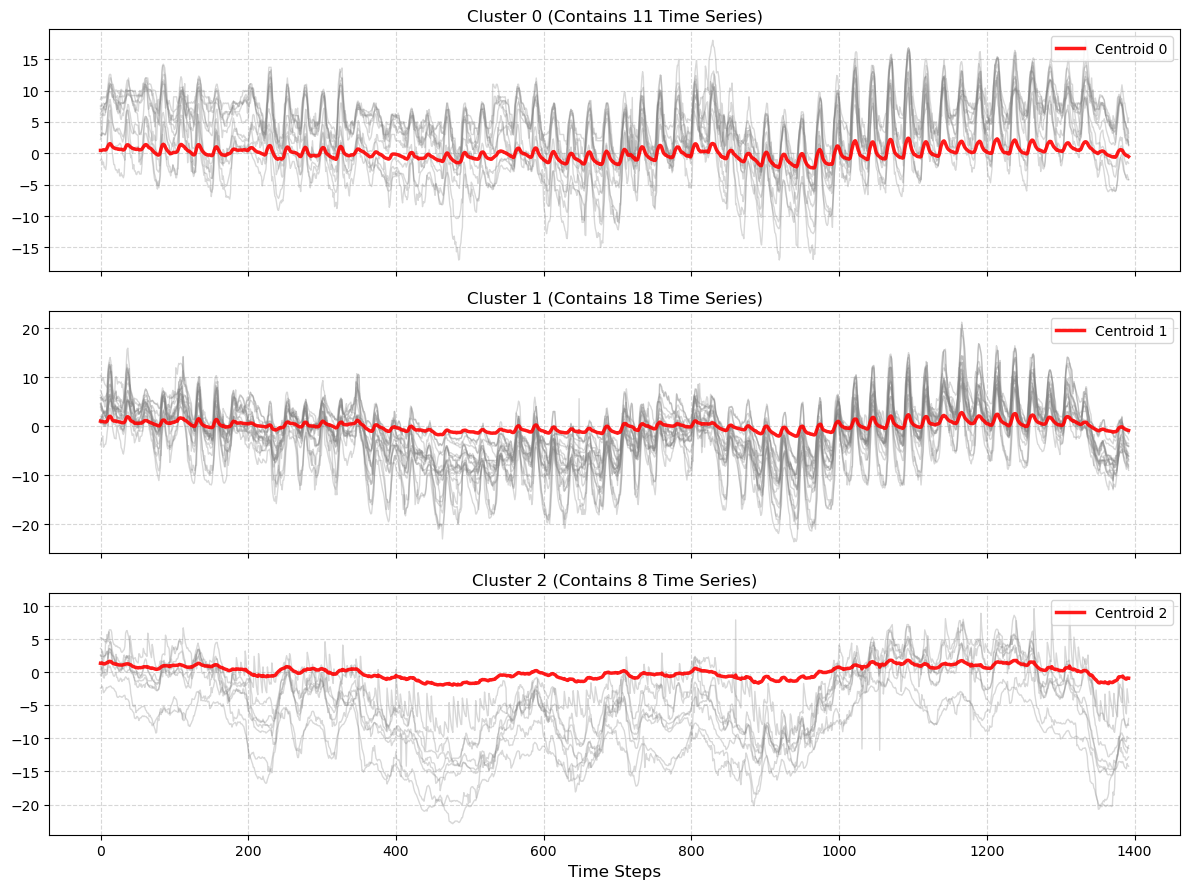

In [93]:
fig, axs = plt.subplots(k, 1, figsize=(12, 3 * k), sharex=True)

for cluster_id in range(k):
    # Find the indices of all time series assigned to the current cluster
    assigned_indices = np.where(cluster_labels == cluster_id)[0]
    
    # Select a specific subplot axis
    ax = axs[cluster_id]
    
    # Plot all individual time series belonging to this cluster in a faint gray color
    # Slicing with [:, :, 0] flattens the tslearn 3D structure back to 2D for plotting
    for idx in assigned_indices:
        ax.plot(X.T[idx, :], color='gray', alpha=0.3, linewidth=1)
    
    # Overlay the Cluster Centroid (the average representative shape) in bold red
    ax.plot(centroids[cluster_id, :], color='red', alpha=0.9, linewidth=2.5, 
            label=f'Centroid {cluster_id}')
    
    # Aesthetic adjustments
    ax.set_title(f'Cluster {cluster_id} (Contains {len(assigned_indices)} Time Series)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

# Set a shared X-axis label at the bottom
plt.xlabel('Time Steps', fontsize=12)
plt.tight_layout()
plt.show()

## K-Shapes

In [68]:
from scipy.stats import zscore

def shape_based_distance(sequence_a, sequence_b):
    m = len(sequence_a)
    fft_len = 1 << (2 * m - 1).bit_length()

    cross_correlation = np.fft.irfft(np.fft.rfft(sequence_a, fft_len) * np.conj(np.fft.rfft(sequence_b, fft_len)))
    cross_correlation = np.concatenate((cross_correlation[-(m - 1):], cross_correlation[:m]), axis=0)

    coeff_norm_cross_correlation = cross_correlation / (np.linalg.norm(sequence_a) * np.linalg.norm(sequence_b))

    index = np.argmax(coeff_norm_cross_correlation)
    value = coeff_norm_cross_correlation[index] 

    dist = 1 - value
    shift = index - (m - 1)
    
    if shift > 0:
        sequence_b_shifted = np.concatenate((np.zeros(shift), sequence_b[:-shift]))
    elif shift < 0:
        sequence_b_shifted = np.concatenate((sequence_b[-shift:], np.zeros(-shift)))
    else:
        sequence_b_shifted = sequence_b.copy()
        
    return dist, sequence_b_shifted

def shape_extraction(time_series_array, reference_time_series):
    n_time_series, n_time_points = time_series_array.shape
    X = np.zeros((n_time_series, n_time_points))

    for i in range(n_time_series):
        _, shifted_time_series = shape_based_distance(reference_time_series, time_series_array[i])
        X[i] = shifted_time_series

    S = X.T @ X
    Q = np.identity(n_time_points) - (1.0 / n_time_points) * np.ones((n_time_points, n_time_points))
    M = Q.T @ S @ Q

    evals, evecs = np.linalg.eigh(M)
    optimum_centroid = evecs[:, np.argmax(evals)]

    if np.dot(optimum_centroid, reference_time_series) < 0:
        optimum_centroid = -optimum_centroid

    return zscore(optimum_centroid)
    

In [72]:
def kshape(time_series_array, k_clusters):
    n_time_series, n_time_points = time_series_array.shape
    iter = 0

    centroids = np.zeros((k_clusters, n_time_points))

    cluster_assignments = np.random.randint(0, k_clusters, n_time_series)
    cluster_assignments_new = cluster_assignments.copy() - 1

    while not np.equal(cluster_assignments, cluster_assignments_new).all() and iter < 100:
        cluster_assignments_new = cluster_assignments.copy()

        for j in range (k_clusters):
            if np.all(centroids[j] == 0):
                reference = time_series_array[np.random.randint(0, len(time_series_array))]
            else:
                reference = centroids[j]
        
            centroids[j] = shape_extraction(time_series_array[cluster_assignments == j], reference)

        for i in range(n_time_series):
            mindist = np.inf

            for j in range(k_clusters):
                dist, _ = shape_based_distance(centroids[j], time_series_array[i])
                
                if dist < mindist:
                    mindist = dist
                    cluster_assignments[i] = j

        iter += 1

    return cluster_assignments, centroids

In [79]:
k = 3
X = df_temp.values.astype(float)

cluster_labels, centroids = kshape(zscore(X.T, axis=1), k)

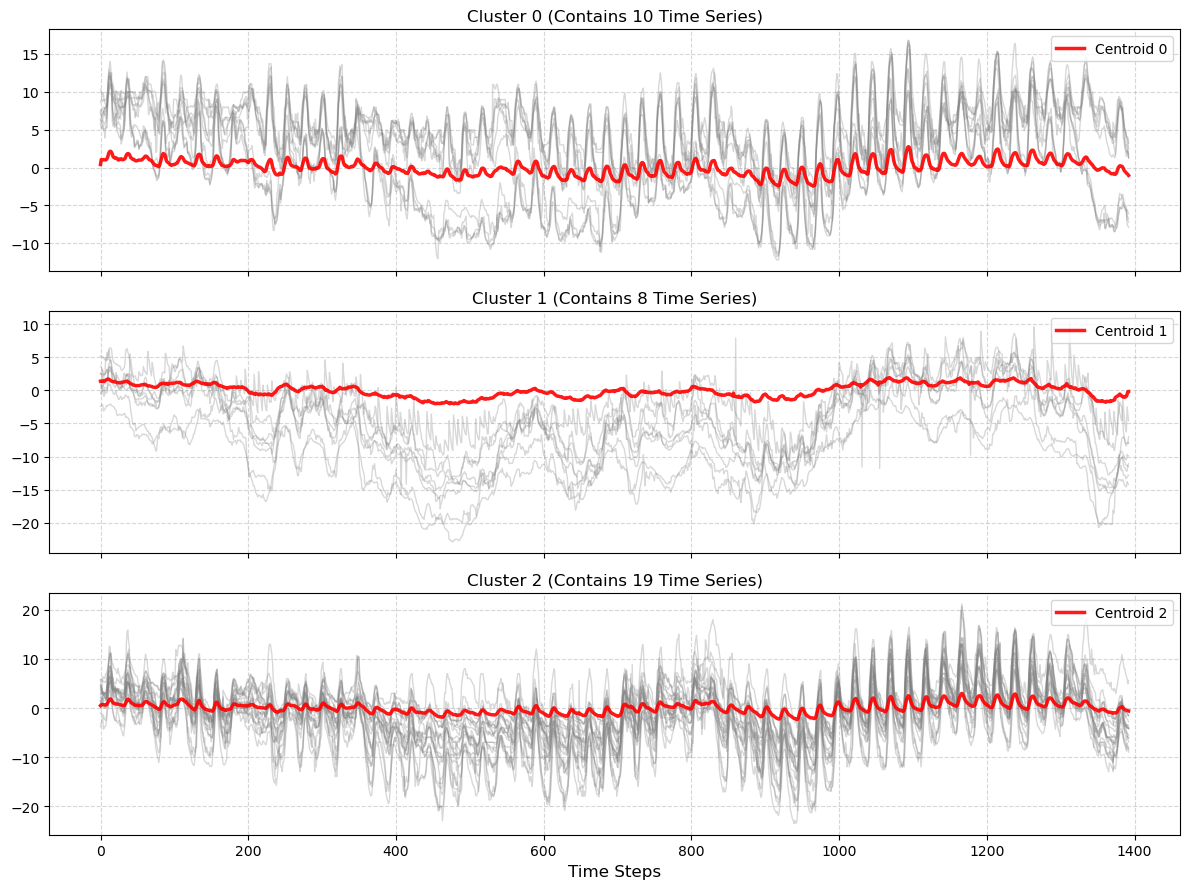

In [80]:
fig, axs = plt.subplots(k, 1, figsize=(12, 3 * k), sharex=True)

for cluster_id in range(k):
    # Find the indices of all time series assigned to the current cluster
    assigned_indices = np.where(cluster_labels == cluster_id)[0]
    
    # Select a specific subplot axis
    ax = axs[cluster_id]
    
    # Plot all individual time series belonging to this cluster in a faint gray color
    # Slicing with [:, :, 0] flattens the tslearn 3D structure back to 2D for plotting
    for idx in assigned_indices:
        ax.plot(X.T[idx, :], color='gray', alpha=0.3, linewidth=1)
    
    # Overlay the Cluster Centroid (the average representative shape) in bold red
    ax.plot(centroids[cluster_id, :], color='red', alpha=0.9, linewidth=2.5, 
            label=f'Centroid {cluster_id}')
    
    # Aesthetic adjustments
    ax.set_title(f'Cluster {cluster_id} (Contains {len(assigned_indices)} Time Series)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

# Set a shared X-axis label at the bottom
plt.xlabel('Time Steps', fontsize=12)
plt.tight_layout()
plt.show()

## DBSCAN

In [116]:
UNCLASSIFIED = 0
NOISE = -1

def region_query(set_of_points, point_idx, eps):
    point = set_of_points[point_idx]
    
    distances = np.linalg.norm(set_of_points - point, axis=1)
    neighbors = np.where(distances <= eps)[0]

    return neighbors.tolist()

def expand_cluster(set_of_points, labels, point_idx, cluster_id, eps, min_pts):
    seeds = region_query(set_of_points, point_idx, eps)

    if len(seeds) < min_pts:
        labels[point_idx] = NOISE
        return False
    
    for idx in seeds:
        labels[idx] = cluster_id

    seeds.remove(point_idx)

    while len(seeds) > 0:
        current_point = seeds[0]

        result = region_query(set_of_points, current_point, eps)

        if len(result) >= min_pts:
            for result_point in result:
                if labels[result_point] == UNCLASSIFIED or labels[result_point] == NOISE:

                    if labels[result_point] == UNCLASSIFIED:
                        seeds.append(result_point)

                    labels[result_point] = cluster_id
        
        seeds.pop(0)

    return True

In [117]:
def dbscan(set_of_points, eps, min_pts):
    n_points = len(set_of_points)
    labels = np.full(n_points, UNCLASSIFIED)
    
    cluster_id = 1

    for i in range(len(set_of_points)):

        if labels[i] == UNCLASSIFIED:
            
            if expand_cluster(set_of_points, labels, i, cluster_id, eps, min_pts):
                cluster_id += 1

    return labels

!!TODO!!

In [130]:
cluster_labels = dbscan(zscore(X.T, axis=1), eps=11, min_pts=5)

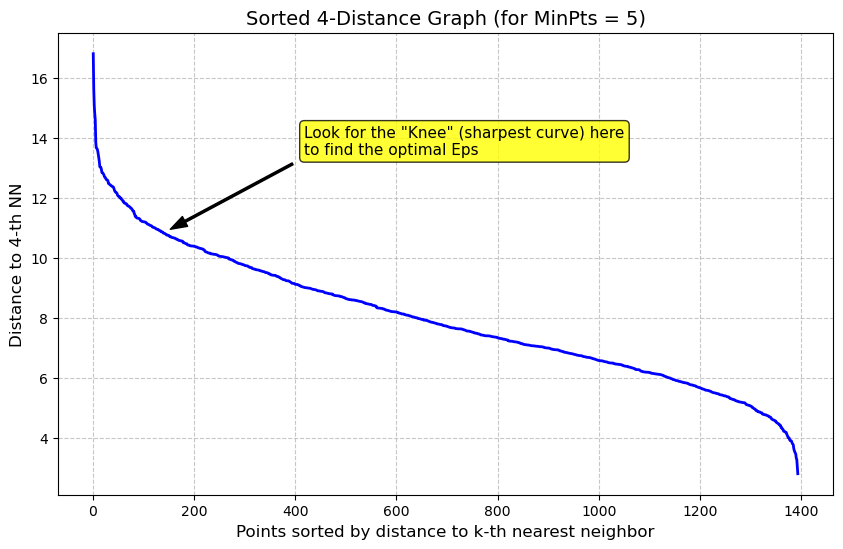

In [127]:
n_samples = len(X)
    
# In the paper, they look at the k-th nearest neighbor.
# If MinPts = 5, a core point needs 4 neighbors (plus itself).
# Therefore, we look at the distance to the 4th nearest neighbor.
k = 5 - 1 

if k >= n_samples:
    raise ValueError("MinPts cannot be greater than the number of samples.")

# 1. Calculate the distance from every time series to every other time series.
# Note: If using DTW, replace this with your DTW distance matrix calculation!
# Here we use Euclidean for demonstration.
# data[:, np.newaxis] broadcasts to create a (N, N, D) matrix of differences
diffs = X[:, np.newaxis] - X
distances = np.linalg.norm(diffs, axis=2)

# 2. Find the distance to the k-th nearest neighbor for each point.
# We sort the distances for each point. 
# Index 0 is the point itself (distance 0). 
# Index k is the k-th nearest neighbor.
kth_distances = np.sort(distances, axis=1)[:, k]

# 3. Sort the resulting k-th distances in DESCENDING order (as per the paper)
sorted_kth_distances = np.sort(kth_distances)[::-1]

# 4. Plot the graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_samples + 1), sorted_kth_distances, linewidth=2, color='b')

plt.title(f'Sorted {k}-Distance Graph (for MinPts = {5})', fontsize=14)
plt.xlabel('Points sorted by distance to k-th nearest neighbor', fontsize=12)
plt.ylabel(f'Distance to {k}-th NN', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Annotate the instruction for the students
plt.annotate('Look for the "Knee" (sharpest curve) here\nto find the optimal Eps', 
                xy=(n_samples * 0.1, sorted_kth_distances[int(n_samples * 0.1)]), 
                xytext=(n_samples * 0.3, sorted_kth_distances[0] * 0.8),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                fontsize=11, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="k", lw=1, alpha=0.8))

plt.show()

{np.int64(-1)}


TypeError: 'Axes' object is not subscriptable

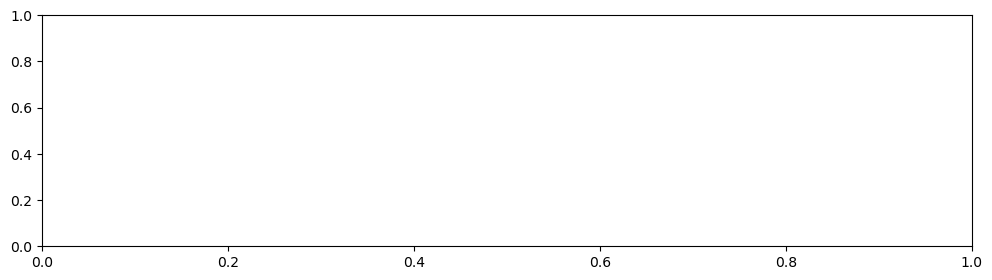

In [131]:
unique_labels = set(cluster_labels)
print(unique_labels)

fig, axs = plt.subplots(len(unique_labels), figsize=(12, 3 * len(unique_labels)), sharex=True)

for cluster_id in unique_labels:
    # Find the indices of all time series assigned to the current cluster
    assigned_indices = np.where(cluster_labels == cluster_id)[0]
    
    # Select a specific subplot axis
    ax = axs[cluster_id]
    
    # Plot all individual time series belonging to this cluster in a faint gray color
    # Slicing with [:, :, 0] flattens the tslearn 3D structure back to 2D for plotting
    for idx in assigned_indices:
        ax.plot(X.T[idx, :], color='gray', alpha=0.3, linewidth=1)
    
    
    # Aesthetic adjustments
    ax.set_title(f'Cluster {cluster_id} (Contains {len(assigned_indices)} Time Series)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

# Set a shared X-axis label at the bottom
plt.xlabel('Time Steps', fontsize=12)
plt.tight_layout()
plt.show()

## Exercises

The kmeans implementation follows MacQueen 1967, which updates the centroids in an online fashion. 

Implement the kmeans by Lloyd, which does so in batches. For an initial centroid choice, you can additionally implement the kmeans++ idea. 

As we've seen, time sereis are not wokring well on pure kmeans. Thus, we provide synthetic data that is more suited for kmean clustering.

Adjust the DBSCAN to improve it to the OPTICS clustering algorithm.